# YAZEL RECOVAR Integration Demo

This notebook demonstrates how RECOVAR can be used to filter false positive picks from PhaseNet.

- **RECOVAR**: Classifies waveforms to distinguish real earthquakes from noise using learned representations
- **RECOVAR YAZEL Integration**: Uses sliding windows to score PhaseNet picks and filter false positives

#### PhaseNet Configuration:
- **Overlap**: 0.90 (90% overlap between windows)
- **Stacking**: avg (average predictions across overlapping windows)
- **Model**: PhaseNet `instance` pretrained model


In [1]:
import matplotlib.pyplot as plt
from demo_plotting import plot_side_by_side_comparison, plot_example, plot_threshold_tradeoff
from demo_utils import load_preprocessed_data, print_confusion_matrix

plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline

### Setup: Load Model and Data

In [2]:
PREPROCESSED_DATA_DIR = 'preprocessed_demo_data'
RECOVAR_THRESHOLD = 0.07

print("Loading preprocessed data...")
tp_examples, fp_examples, tp_metadata, fp_metadata = load_preprocessed_data(PREPROCESSED_DATA_DIR)

print(f"Loaded {len(tp_examples)} TRUE PICK examples")
print(f"Loaded {len(fp_examples)} FALSE PICK examples")

Loading preprocessed data...
Loaded 493 TRUE PICK examples
Loaded 1682 FALSE PICK examples


## RECOVAR Filtering Examples

- **TRUE PICKS**: PhaseNet picks that match catalog events (real earthquakes)
- **FALSE PICKS**: PhaseNet picks without catalog events (noise/artifacts)

Demonstrating RECOVAR's filtering performance with threshold = 0.07 (max score):
- **TRUE PICK + Kept**: Real earthquake that RECOVAR correctly kept
- **TRUE PICK + Filtered**: Real earthquake that RECOVAR incorrectly rejected  
- **FALSE PICK + Filtered**: Noise/artifact that RECOVAR correctly rejected
- **FALSE PICK + Kept**: Noise/artifact that RECOVAR incorrectly kept

In [3]:
# RECOVAR scores are already loaded in the examples (precomputed!)
print(f"RECOVAR scores loaded for {len(tp_examples)} TRUE PICKS and {len(fp_examples)} FALSE PICKS")

# Extract for threshold analysis
tp_max_scores = [ex['max_score'] for ex in tp_examples]
fp_max_scores = [ex['max_score'] for ex in fp_examples]

RECOVAR scores loaded for 493 TRUE PICKS and 1682 FALSE PICKS


TRUE PICKS kept by RECOVAR: 489
TRUE PICKS filtered by RECOVAR: 4
FALSE PICKS kept by RECOVAR: 878
FALSE PICKS filtered by RECOVAR: 804

CORRECT DECISIONS: TRUE PICKS KEPT (left) vs FALSE PICKS FILTERED (right)

Example pair 1


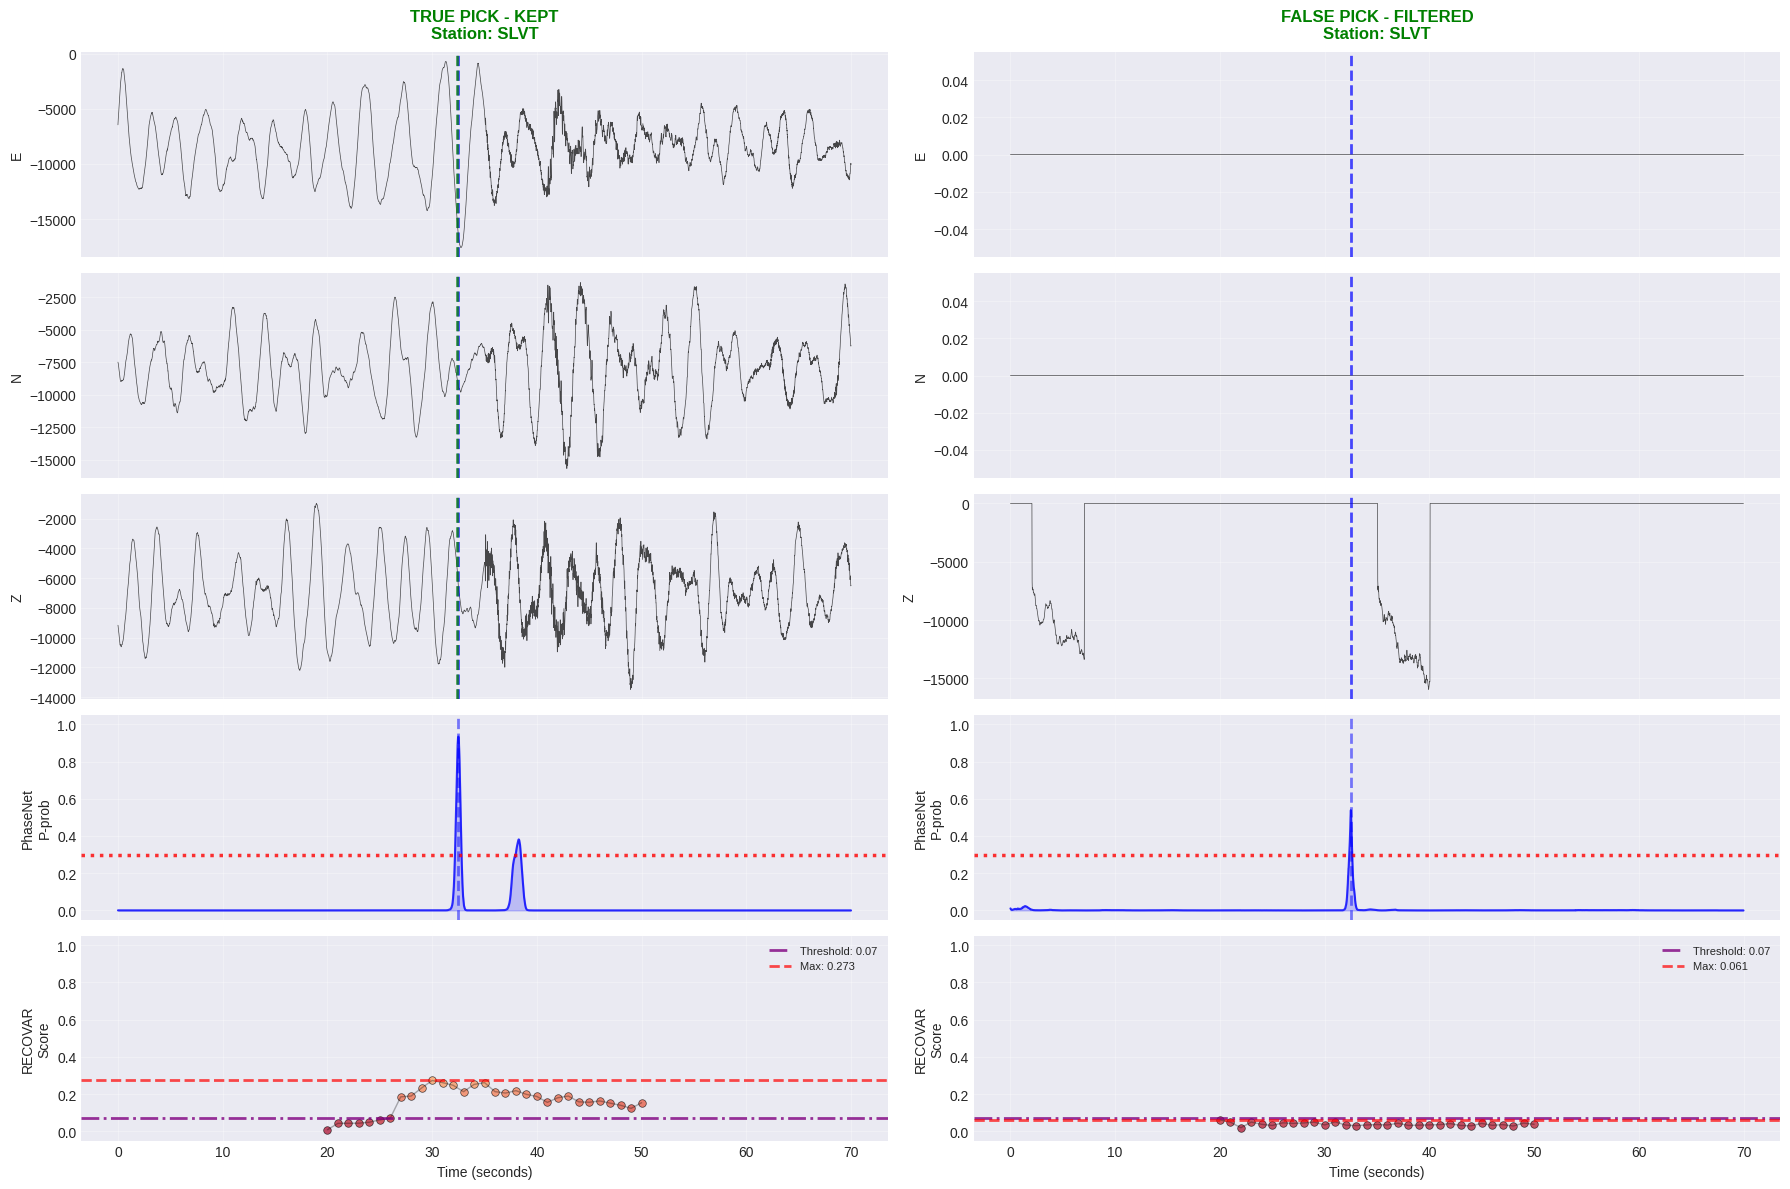


Example pair 2


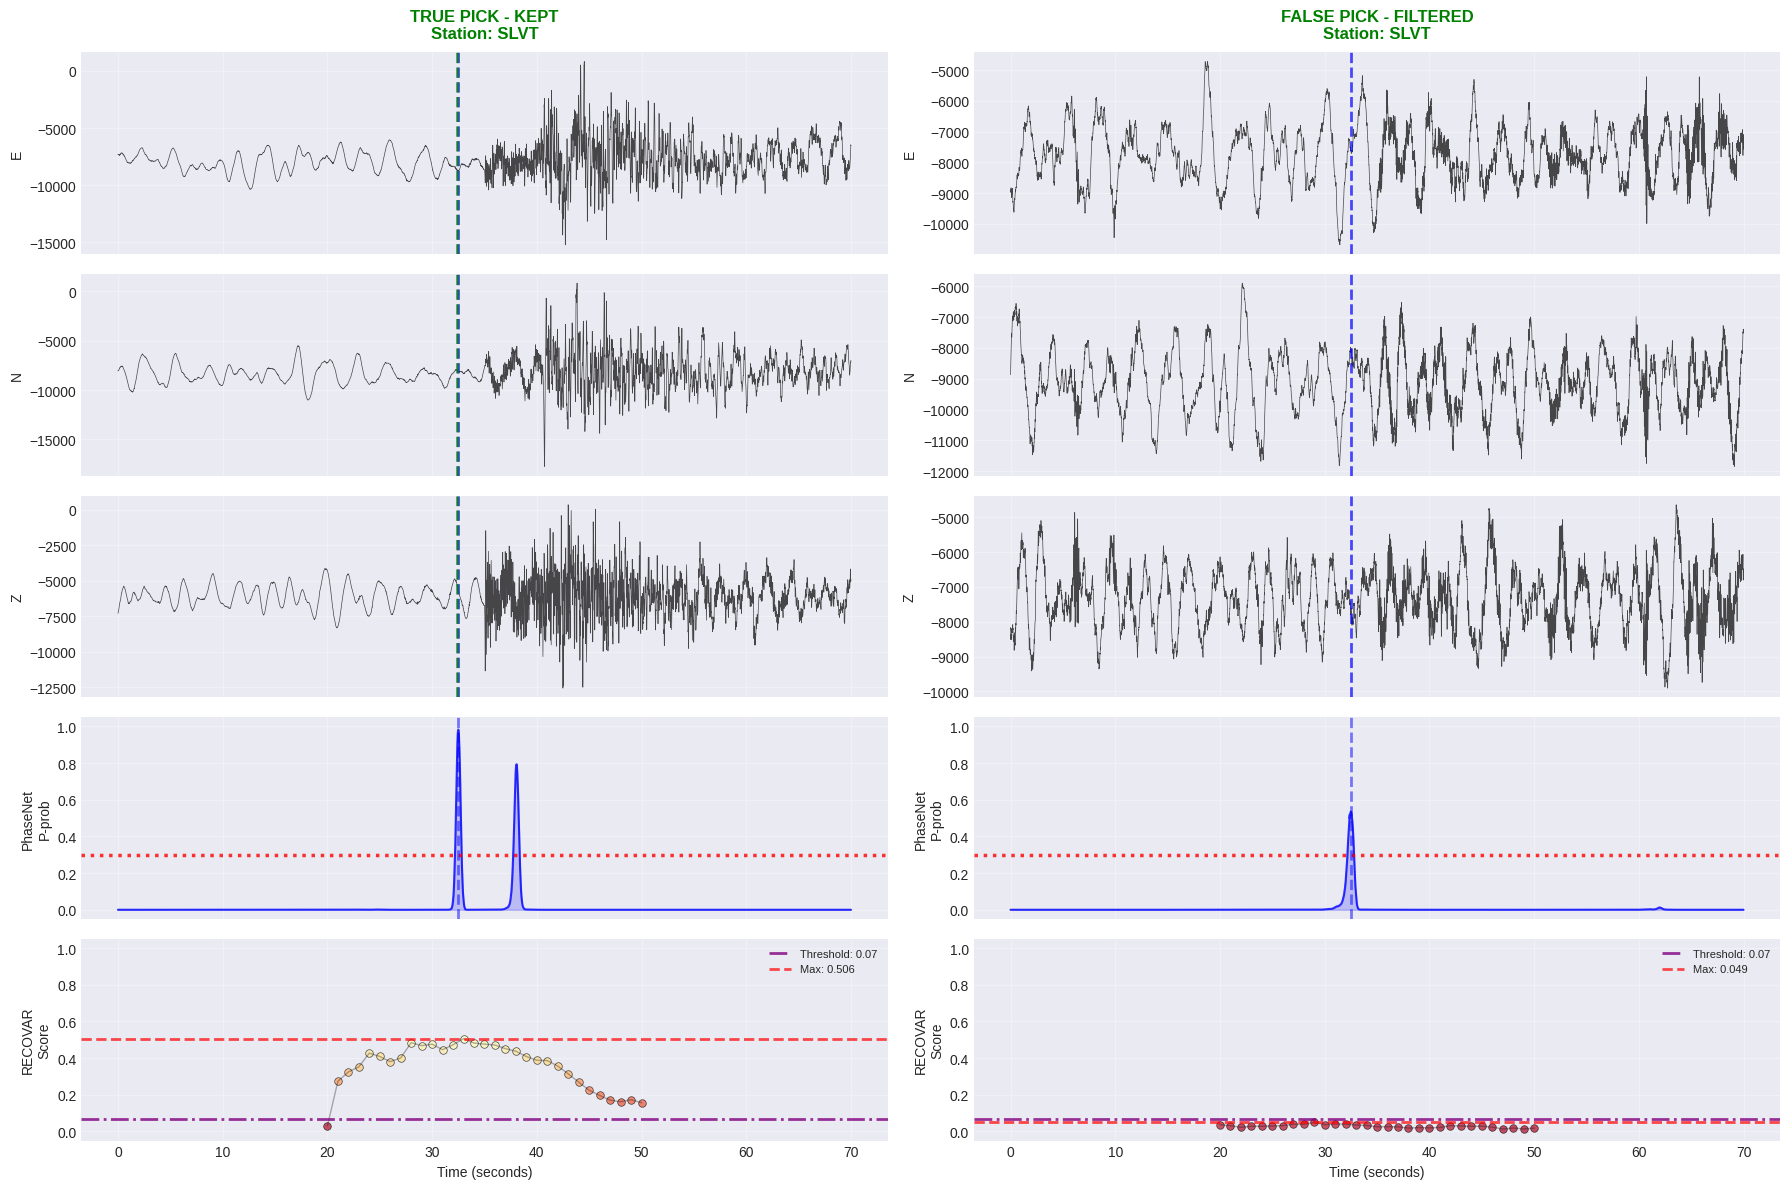


Example pair 3


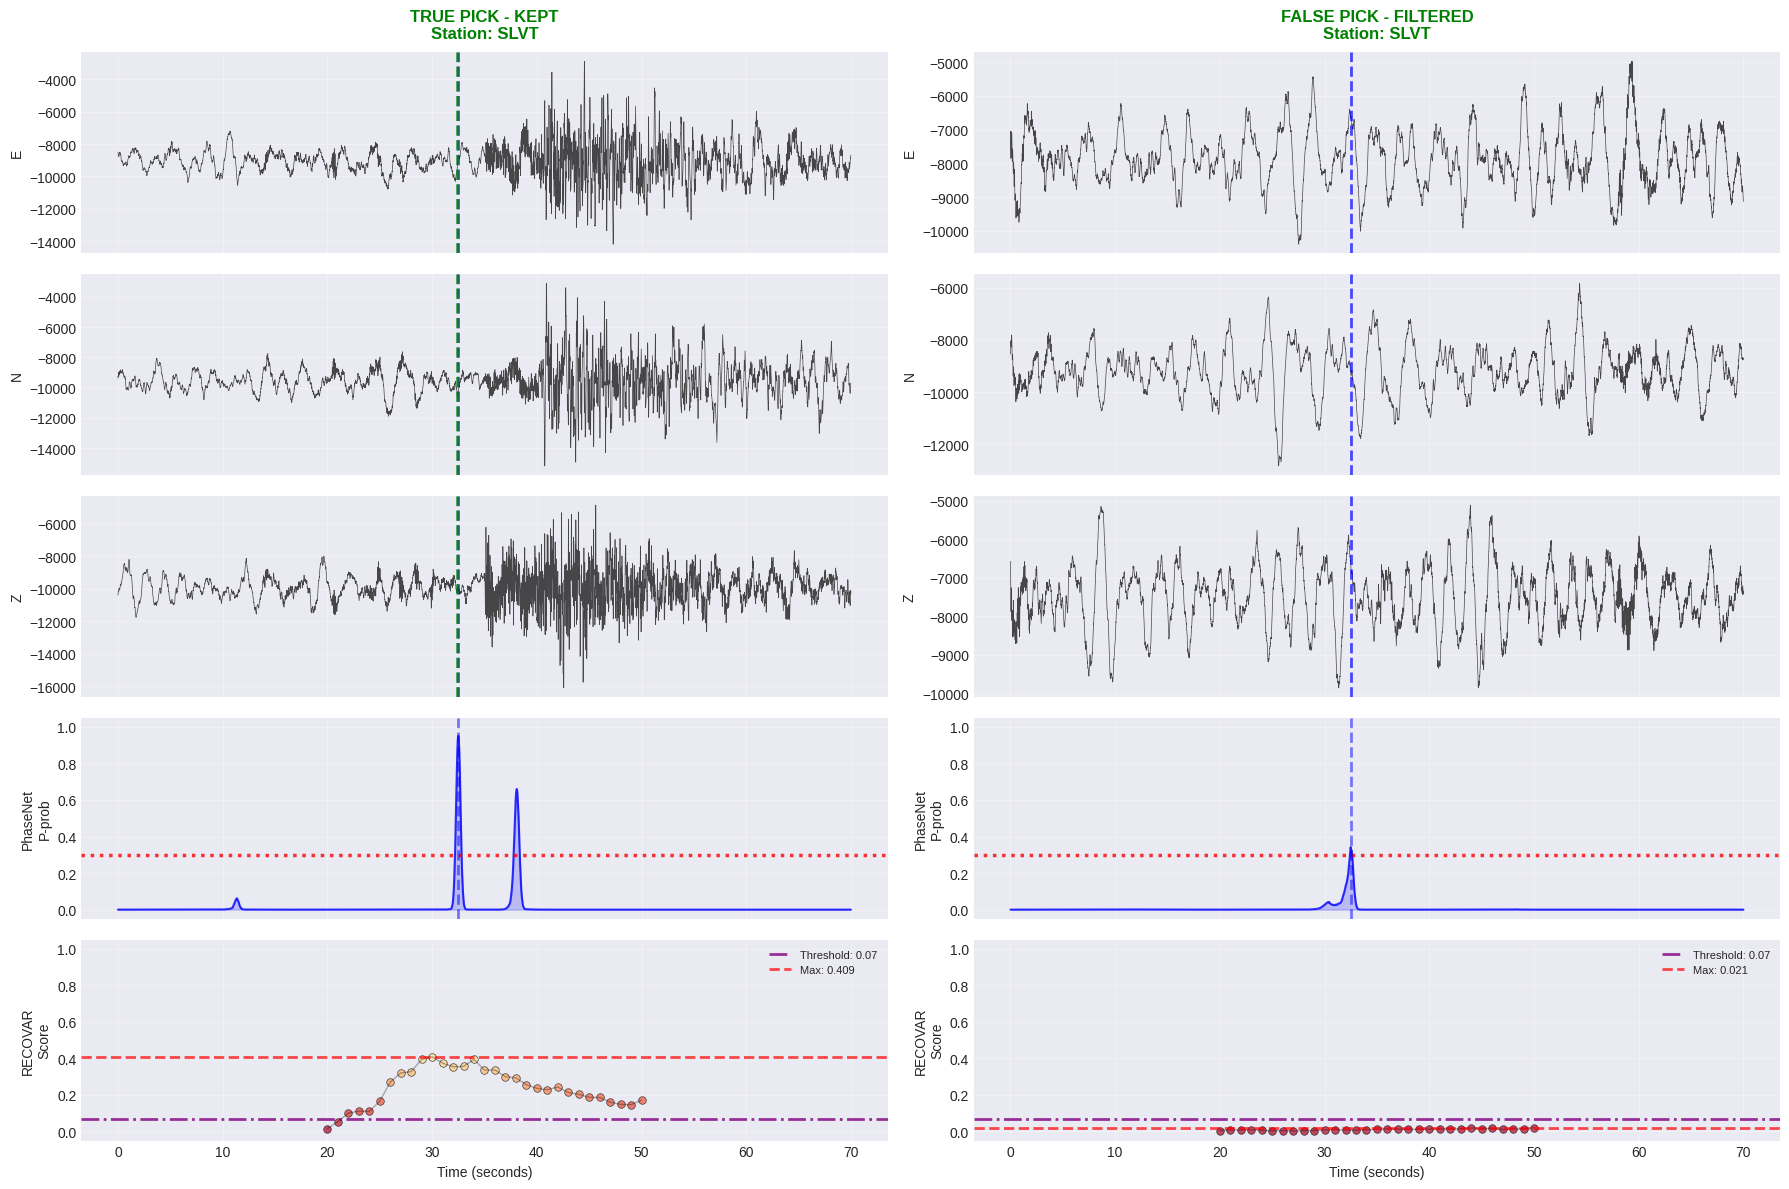


INCORRECT DECISIONS: TRUE PICKS FILTERED (left) vs FALSE PICKS KEPT (right)

Example pair 1


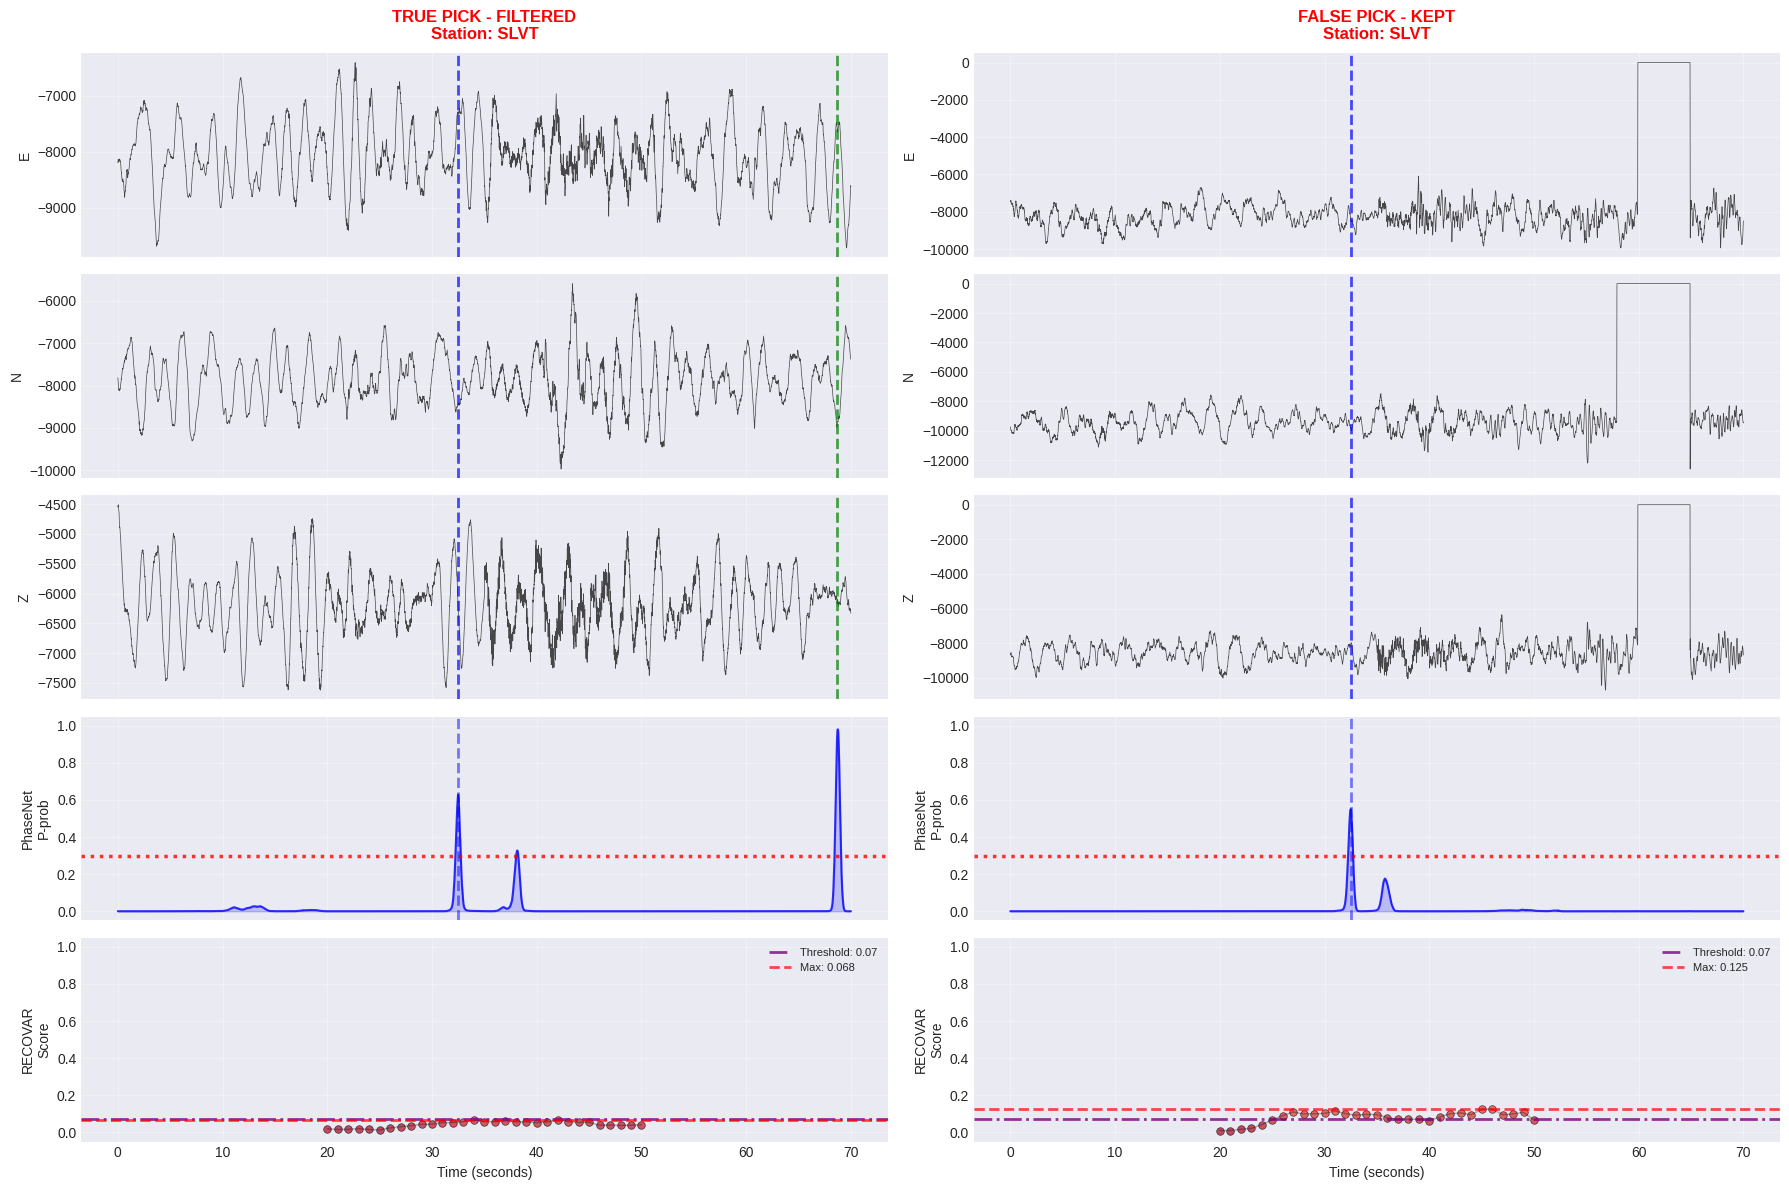


Example pair 2


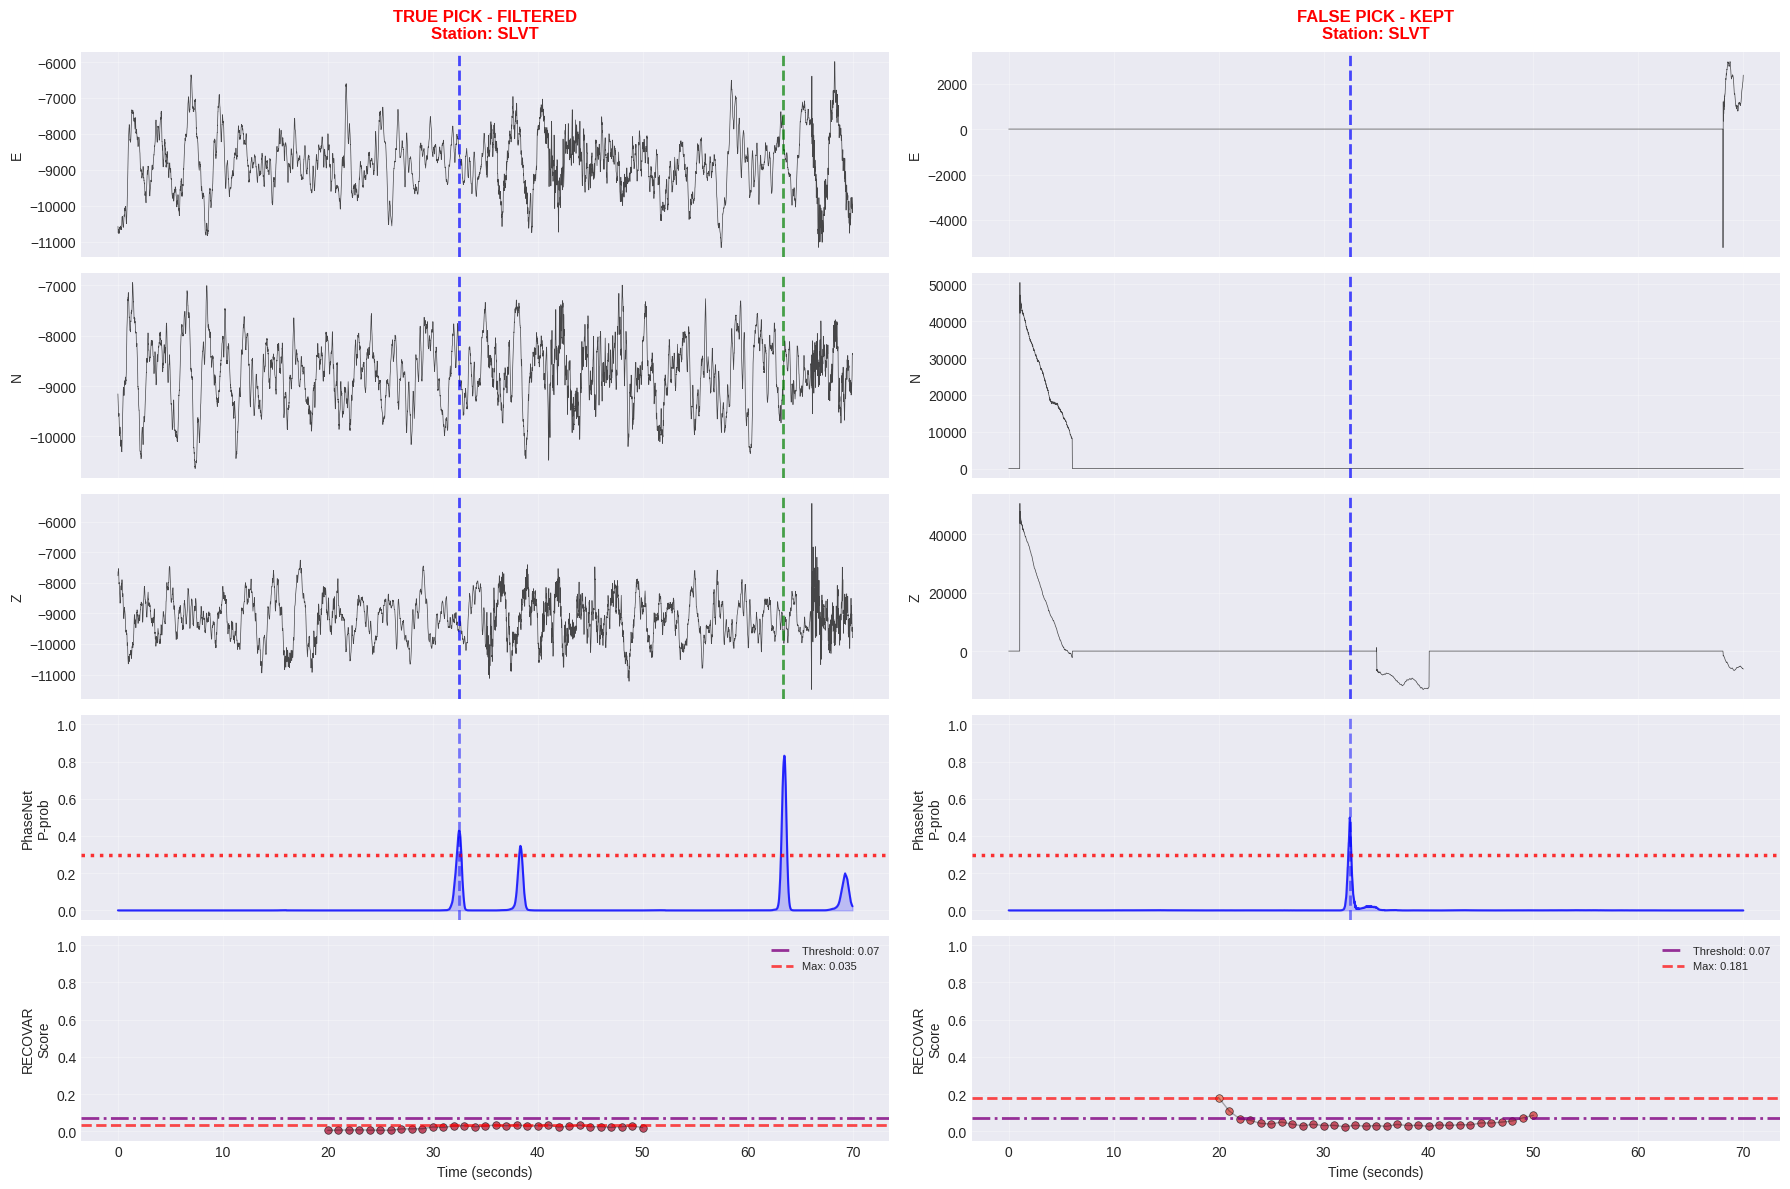


Example pair 3


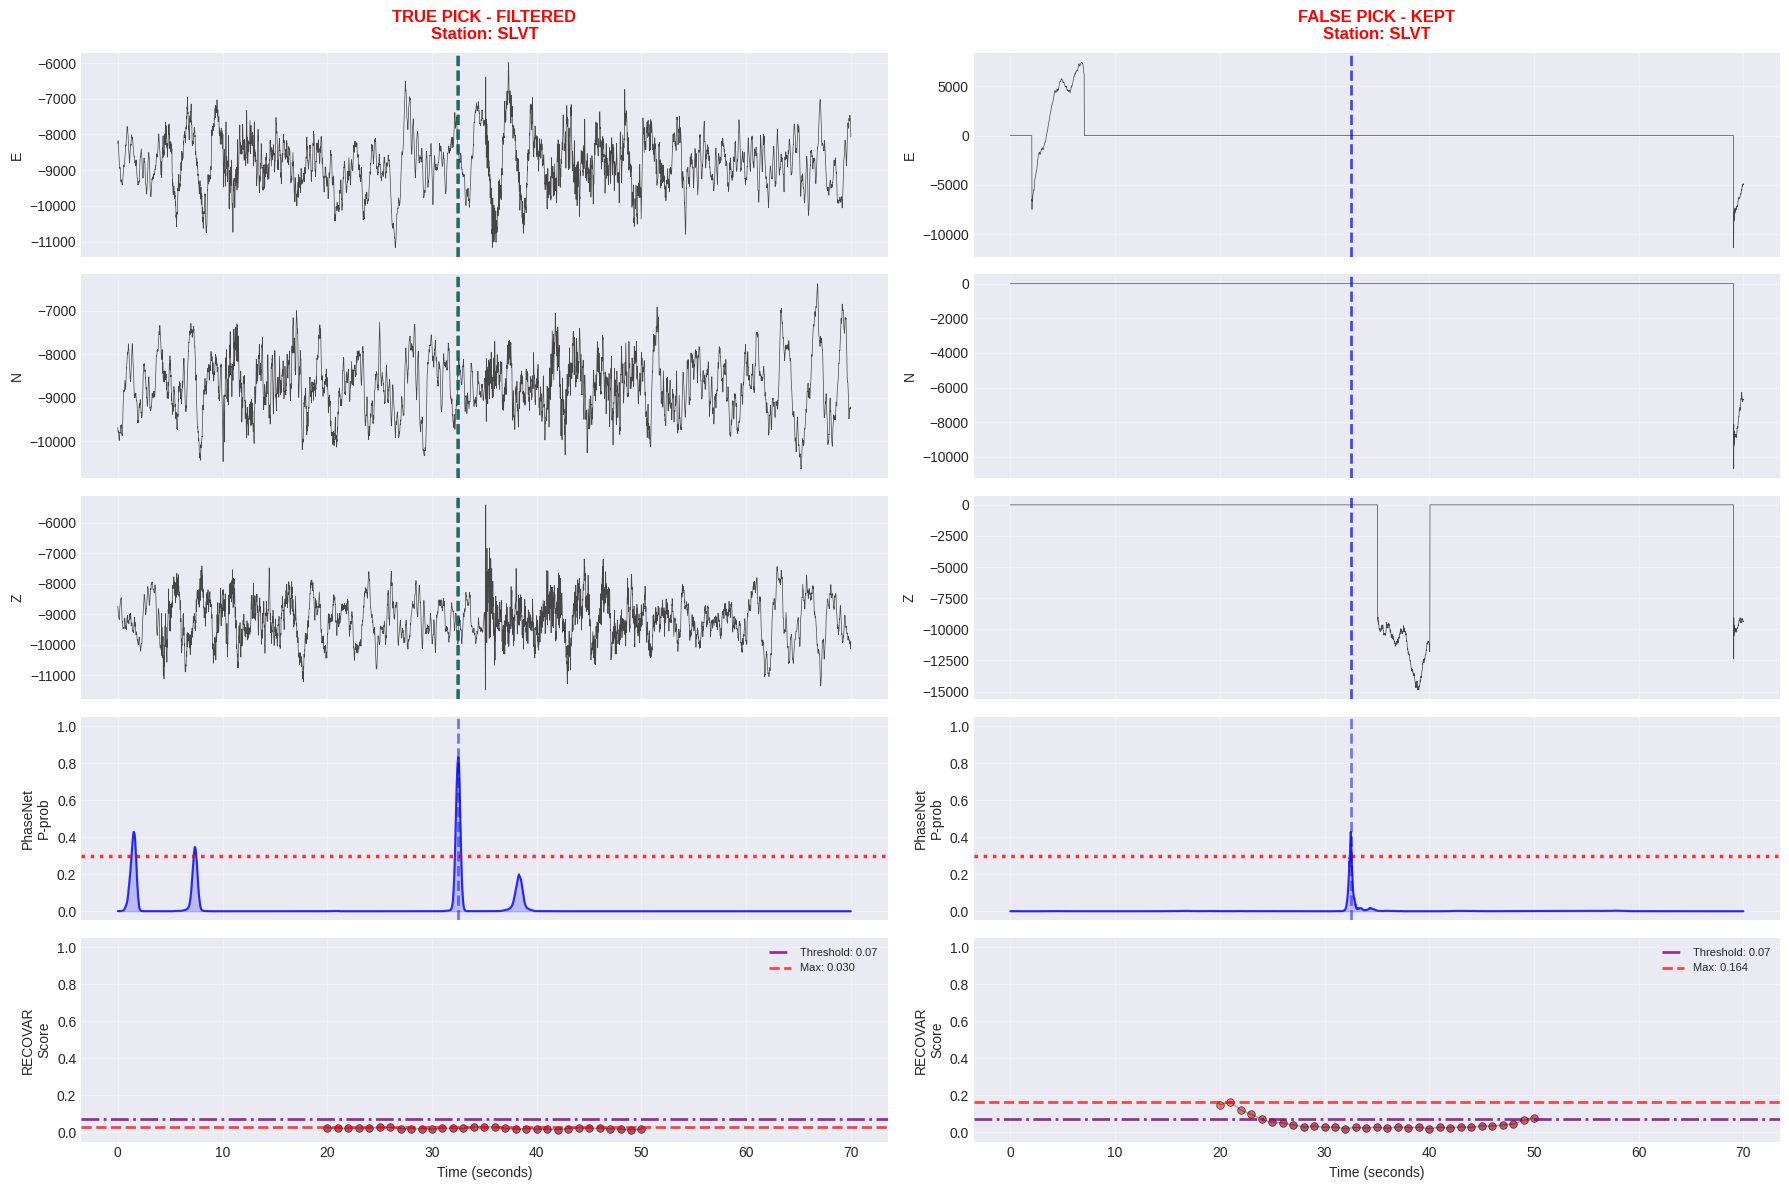

In [4]:
tp_kept = [ex for ex in tp_examples if ex['max_score'] >= RECOVAR_THRESHOLD]
tp_filtered = [ex for ex in tp_examples if ex['max_score'] < RECOVAR_THRESHOLD]
fp_kept = [ex for ex in fp_examples if ex['max_score'] >= RECOVAR_THRESHOLD]
fp_filtered = [ex for ex in fp_examples if ex['max_score'] < RECOVAR_THRESHOLD]

print(f"TRUE PICKS kept by RECOVAR: {len(tp_kept)}")
print(f"TRUE PICKS filtered by RECOVAR: {len(tp_filtered)}")
print(f"FALSE PICKS kept by RECOVAR: {len(fp_kept)}")
print(f"FALSE PICKS filtered by RECOVAR: {len(fp_filtered)}")

num_examples_to_show = 3

# Correct decisions: TRUE PICKS KEPT vs FALSE PICKS FILTERED
if tp_kept and fp_filtered:
    print("\n" + "="*80)
    print("CORRECT DECISIONS: TRUE PICKS KEPT (left) vs FALSE PICKS FILTERED (right)")
    print("="*80)
    for i in range(min(num_examples_to_show, len(tp_kept), len(fp_filtered))):
        print(f"\nExample pair {i+1}")
        plot_side_by_side_comparison(
            tp_kept[i], tp_kept[i]['recovar_result'], tp_kept[i]['phasenet_result'],
            fp_filtered[i], fp_filtered[i]['recovar_result'], fp_filtered[i]['phasenet_result'],
            threshold=RECOVAR_THRESHOLD
        )

# Incorrect decisions: TRUE PICKS FILTERED vs FALSE PICKS KEPT
if tp_filtered and fp_kept:
    print("\n" + "="*80)
    print("INCORRECT DECISIONS: TRUE PICKS FILTERED (left) vs FALSE PICKS KEPT (right)")
    print("="*80)
    for i in range(min(num_examples_to_show, len(tp_filtered), len(fp_kept))):
        print(f"\nExample pair {i+1}")
        plot_side_by_side_comparison(
            tp_filtered[i], tp_filtered[i]['recovar_result'], tp_filtered[i]['phasenet_result'],
            fp_kept[i], fp_kept[i]['recovar_result'], fp_kept[i]['phasenet_result'],
            threshold=RECOVAR_THRESHOLD
        )

if tp_filtered and not fp_kept:
    print("\n" + "="*80)
    print("FALSE NEGATIVES: TRUE PICKS FILTERED BY RECOVAR")
    print("="*80)
    for i in range(min(num_examples_to_show, len(tp_filtered))):
        print(f"\nExample {i+1}")
        plot_example(tp_filtered[i], tp_filtered[i]['recovar_result'], 
                    tp_filtered[i]['phasenet_result'], threshold=RECOVAR_THRESHOLD)

if fp_kept and not tp_filtered:
    print("\n" + "="*80)
    print("FALSE POSITIVES: FALSE PICKS KEPT BY RECOVAR")
    print("="*80)
    for i in range(min(num_examples_to_show, len(fp_kept))):
        print(f"\nExample {i+1}")
        plot_example(fp_kept[i], fp_kept[i]['recovar_result'], 
                    fp_kept[i]['phasenet_result'], threshold=RECOVAR_THRESHOLD)

### Performance Metrics at Recommended Threshold (0.07)

In [5]:
print_confusion_matrix(tp_kept, tp_filtered, fp_kept, fp_filtered, RECOVAR_THRESHOLD)

Performance at threshold = 0.07:
  Catalog Events RECOVAR kept (TP):   489 
  Catalog Events Recovar lost (FN):    4 
  False Phasenet Pick Recovar FILTERED (TN):   804
  False Phasenet Pick Recovar KEPT (FP):  878 


### Threshold Trade-off Analysis

This plot shows how different thresholds affect the filtering performance:
- **Missed True Picks**: Real earthquakes that would be filtered out 
- **Filtered False Picks**: Noise that would be correctly removed 

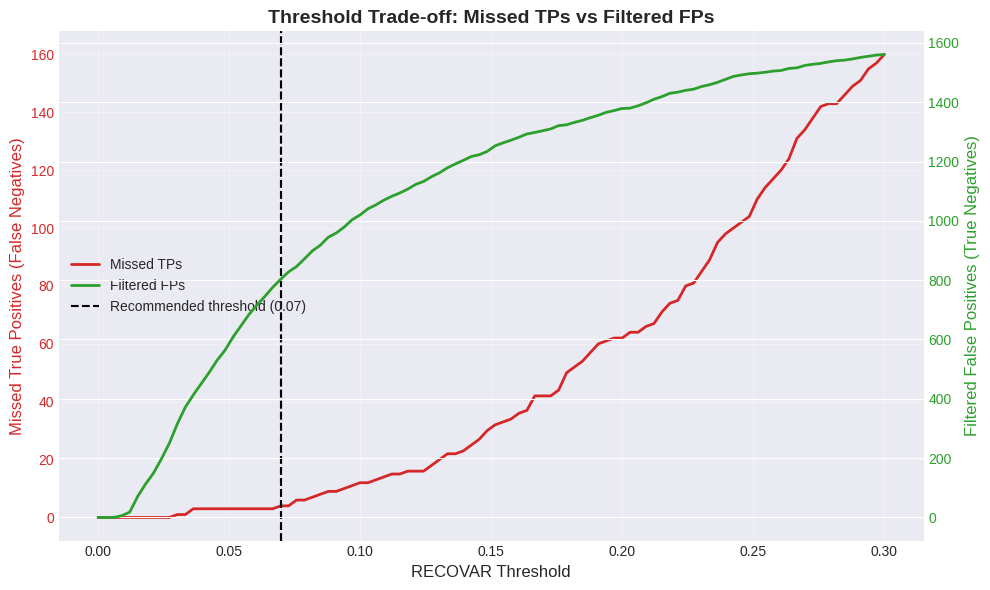


At recommended threshold 0.07:
  Missed TPs: 4/493
  Filtered FPs: 803/1682


(4, 803)

In [6]:
plot_threshold_tradeoff(tp_max_scores, fp_max_scores, RECOVAR_THRESHOLD)

For details on RECOVAR integration functions, see `run_yazel_batch_sliding.py`